In [12]:
#Task 1A
#imports
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Load data
#skip first row as it contains the column header
df_large = pd.read_csv("datasets/REQUEST_FOR_DELETION.csv",
                       names=["thread_subject", "username", "page_name"],
                       skiprows=1)
df_medium = pd.read_csv("datasets/USERS.csv",
                        names= ["thread_subject", "username", "page_name"],
                        skiprows=1)
df_small = pd.read_csv("datasets/BOT_REQUESTS.csv",
                        names= ["thread_subject", "username", "page_name"],
                        skiprows=1)

#Exploring data- sanity check 
for name, df in [("REQUEST_FOR_DELETION", df_large),
                 ("USERS", df_medium),
                 ("BOT_REQUESTS", df_small)]:
    print(f"=== {name} ===")
    print(f"  Total rows:     {len(df)}")
    print(f"  Unique editors: {df['username'].nunique()}")
    print(f"  Unique threads: {df['thread_subject'].nunique()}")
    print(f"  Unique pages:   {df['page_name'].nunique()}")
    print()



=== REQUEST_FOR_DELETION ===
  Total rows:     648644
  Unique editors: 9935
  Unique threads: 316296
  Unique pages:   3303

=== USERS ===
  Total rows:     171692
  Unique editors: 11387
  Unique threads: 34394
  Unique pages:   65076

=== BOT_REQUESTS ===
  Total rows:     2985
  Unique editors: 552
  Unique threads: 1115
  Unique pages:   108



In [4]:
#Nodes = editors (unique usernames)
#Edges = two editors commented in the same thread on the same page
#Weight = number of times two editors co-appeared (how often they interacted)
#Extra info (page names, thread subjects) stays in the pandas DataFrame
#since networkx edges can only store numeric/simple attributes directly
#I used combinations() instead of a nested loop as it autimatically generates all unique
#pairs without repeating them
def build_network(df):
    G = nx.Graph()
    
    #Group by page and thread (each group is one conversation)
    grouped = df.groupby(["page_name", "thread_subject"])
    
    for (page, thread), group in grouped:
        users = group["username"].unique().tolist()
        
        # Connect every pair of editors in the same thread
        for u1, u2 in combinations(users, 2):
            if G.has_edge(u1, u2):
                G[u1][u2]["weight"] += 1
            else:
                G.add_edge(u1, u2, weight=1)
    return G

In [5]:
#Build all 3 networks
print("Building large network...")
G_large  = build_network(df_large)
print("Building medium network...")
G_medium = build_network(df_medium)
print("Building small network...")
G_small  = build_network(df_small)
print("Done!!! Yay!!")

Building large network...
Building medium network...
Building small network...
Done!!! Yay!!


In [6]:
#Summary 
for name, G in [("REQUEST_FOR_DELETION (Large)", G_large),
                ("USERS (Medium)",               G_medium),
                ("BOT_REQUESTS (Small)",          G_small)]:
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"=== {name} ===")
    print(f"  Nodes:                      {G.number_of_nodes()}")
    print(f"  Edges:                      {G.number_of_edges()}")
    print(f"  Connected components:       {nx.number_connected_components(G)}")
    print(f"  Nodes in largest component: {len(largest_cc)}")
    print()

=== REQUEST_FOR_DELETION (Large) ===
  Nodes:                      9887
  Edges:                      33488
  Connected components:       9
  Nodes in largest component: 9870

=== USERS (Medium) ===
  Nodes:                      8390
  Edges:                      24692
  Connected components:       265
  Nodes in largest component: 7767

=== BOT_REQUESTS (Small) ===
  Nodes:                      527
  Edges:                      2425
  Connected components:       4
  Nodes in largest component: 519



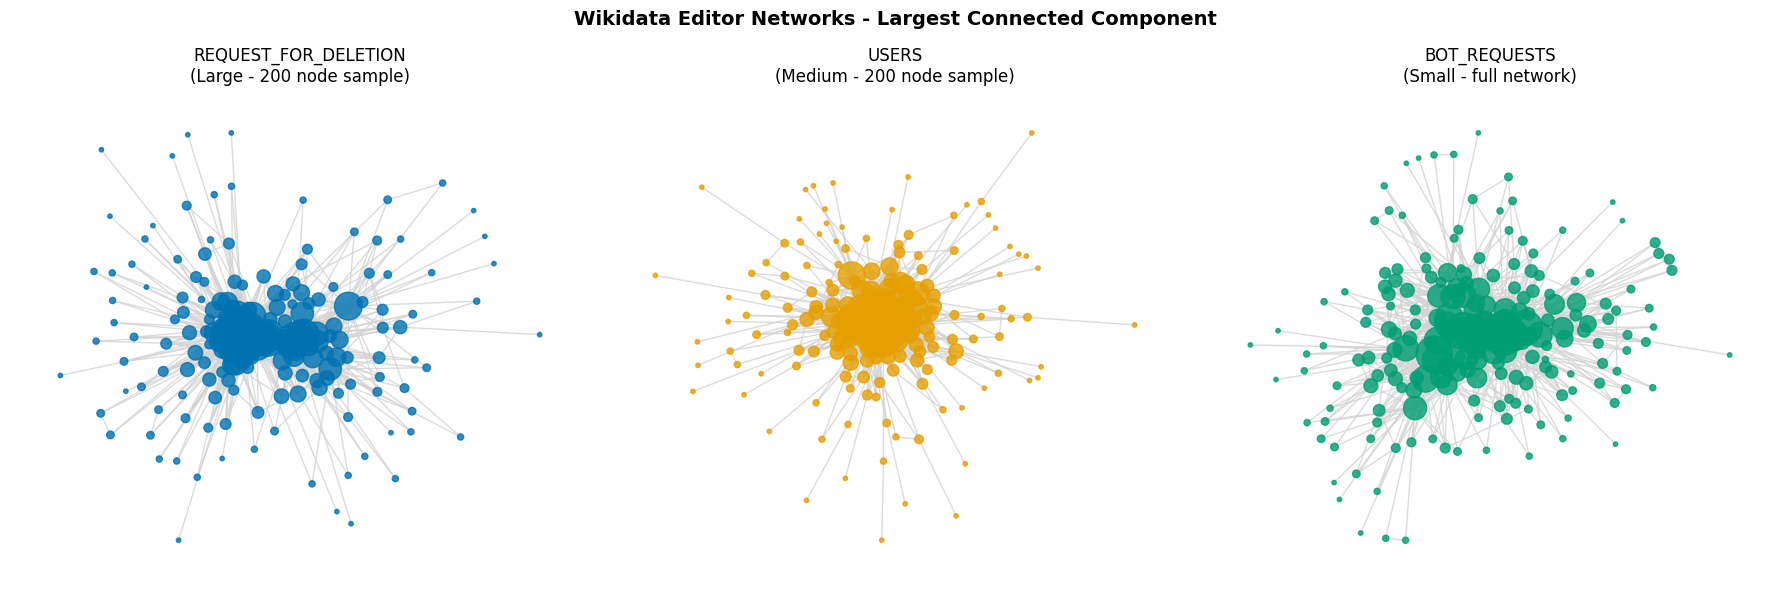

In [7]:
#Data vis
#Large and medium networks are sampled (200 nodes) as the full 
#graph is too dense to visualise meaningfully.
#Node size is scaled by degree to highlight hub editors.

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
networks = [
    (G_large,  "REQUEST_FOR_DELETION\n(Large - 200 node sample)", "#0072B2"),
    (G_medium, "USERS\n(Medium - 200 node sample)",               "#E69F00"),
    (G_small,  "BOT_REQUESTS\n(Small - full network)",            "#009E73")
]

for ax, (G, title, colour) in zip(axes, networks):
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    
    if G.number_of_nodes() > 200:
        sample_nodes = list(G_sub.nodes())[:200]
        G_plot = G_sub.subgraph(sample_nodes)
    else:
        G_plot = G_sub
    
    degrees = dict(G_plot.degree())
    node_sizes = [degrees[n] * 10 for n in G_plot.nodes()]
    
    pos = nx.spring_layout(G_plot, seed=42)
    nx.draw(G_plot, pos=pos, ax=ax,
            node_size=node_sizes,
            node_color=colour,
            edge_color='lightgray',
            alpha=0.8,
            with_labels=False)
    ax.set_title(title, fontsize=12)

plt.suptitle("Wikidata Editor Networks - Largest Connected Component",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('network_comparison.png', dpi=150)
plt.show()

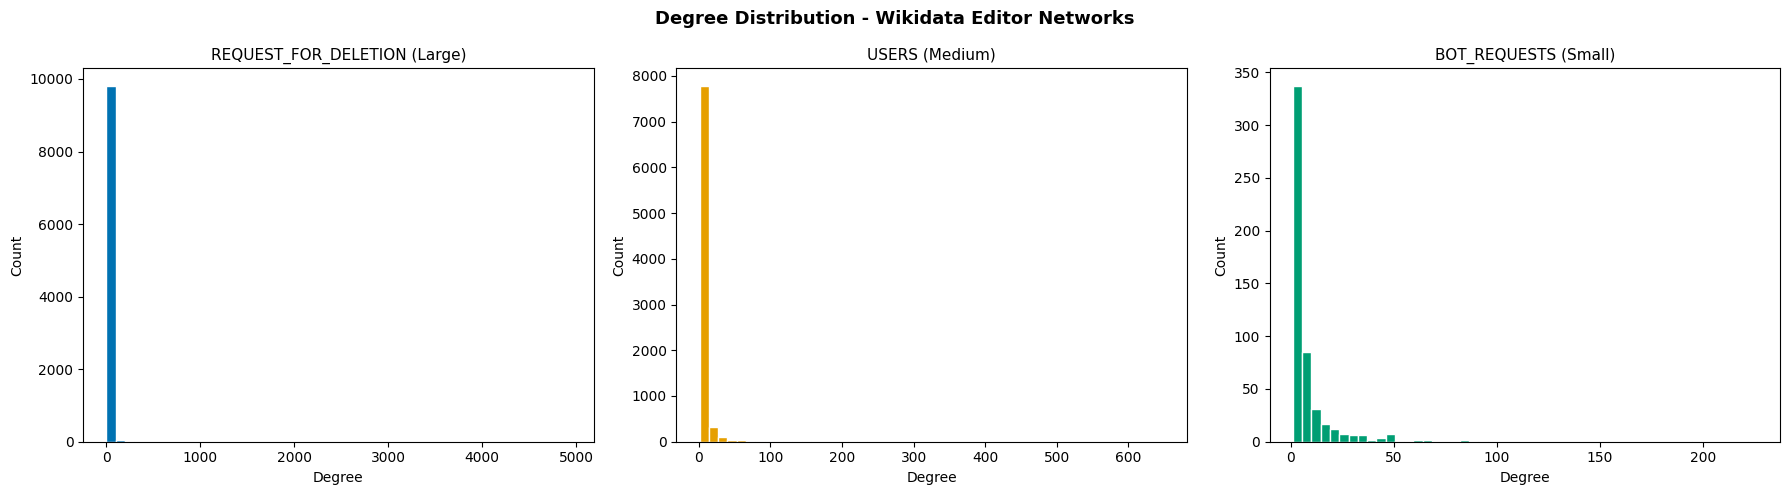

In [8]:
#Task 1B- Network Metrics
#Degree distribution to see how connected each editor is
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

networks = [
    (G_large,  "REQUEST_FOR_DELETION (Large)", "#0072B2"),
    (G_medium, "USERS (Medium)",               "#E69F00"),
    (G_small,  "BOT_REQUESTS (Small)",          "#009E73")
]
for ax, (G, title, colour) in zip(axes, networks):
    degree_sequence = [d for n, d in G.degree()]
    ax.hist(degree_sequence, bins=50, color=colour, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Count")

plt.suptitle("Degree Distribution - Wikidata Editor Networks",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('degree_distribution.png', dpi=150)
plt.show()

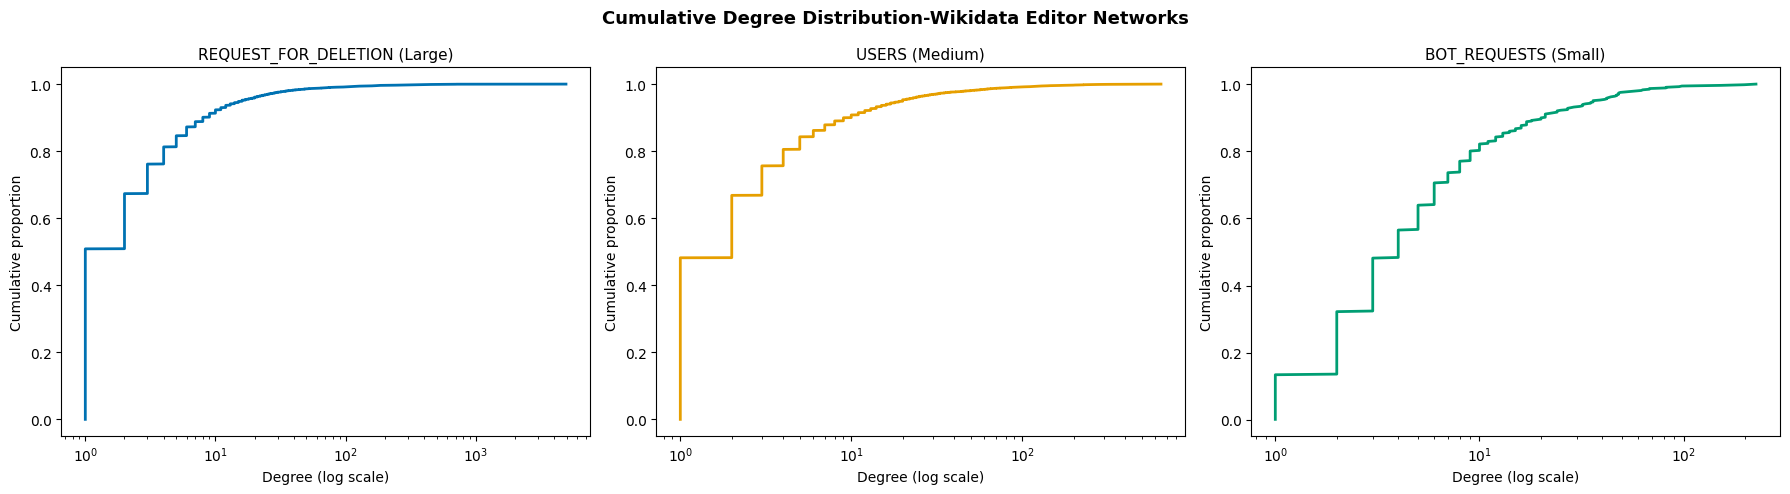

In [11]:
#Cumulative Degree Ditribution (CDF)
#Shows proportion of nodes with degree less than or equal to k
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (G, title, colour) in zip(axes, networks):
    degree_sequence = sorted([d for n, d in G.degree()])
    
    # Calculate CDF
    cdf = np.arange(1, len(degree_sequence)+1)/len(degree_sequence)
    
    ax.plot(degree_sequence, cdf, color=colour, linewidth=2)
    ax.set_xscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Degree (log scale)")
    ax.set_ylabel("Cumulative proportion")

plt.suptitle("Cumulative Degree Distribution-Wikidata Editor Networks",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("degree_cdf.png", dpi=150)
plt.show()

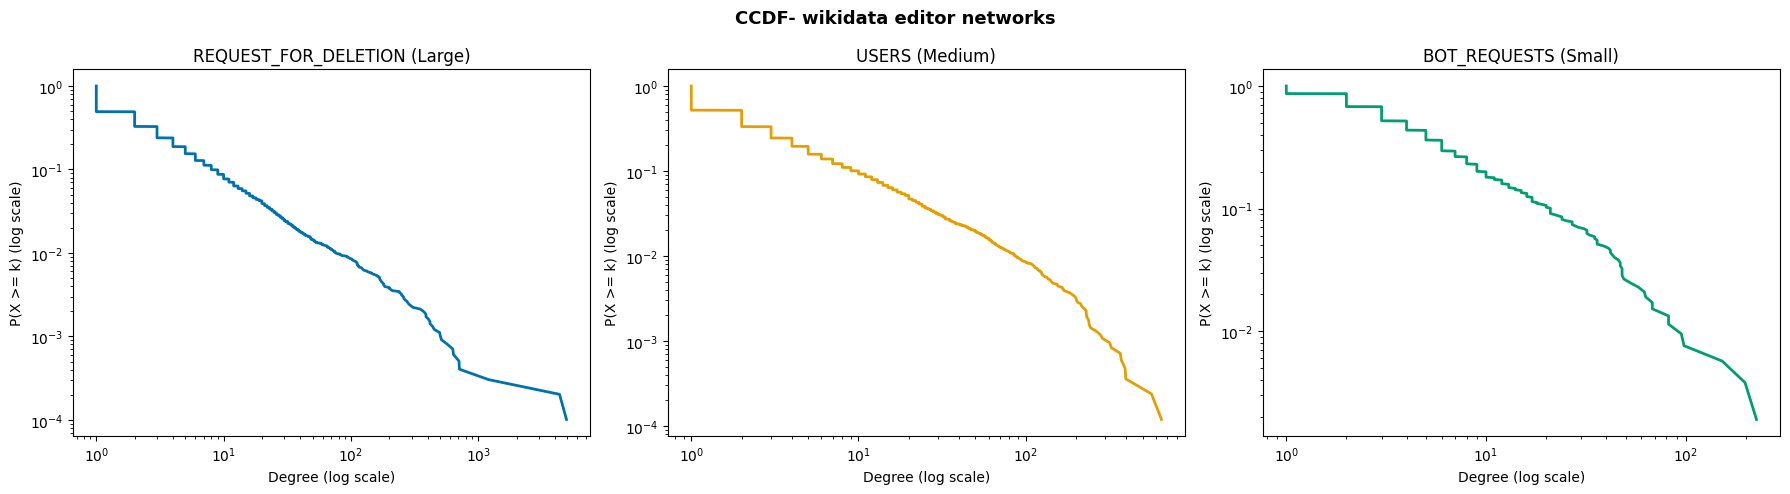

In [17]:
#complementary cumulative degree distribution (CCDF) on a log log scale
#A striahgt line on log log suggests power law behaviour (scale free network)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (G, title, colour) in zip(axes, networks):
    degree_sequence = sorted([d for n, d in G.degree()], reverse = True)
    ccdf= np.arange(1, len(degree_sequence)+1)/len(degree_sequence)

    ax.plot(degree_sequence, ccdf, color= colour, linewidth=2)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Degree (log scale)")
    ax.set_ylabel("P(X >= k) (log scale)")

plt.suptitle("CCDF- wikidata editor networks" ,fontsize = 13, fontweight= "bold")
plt.tight_layout()
plt.savefig("degree_ccdf.png", dpi = 150)
plt.show()
    

In [10]:
#Calculating metrics for each network

for name, G in [("REQUEST_FOR_DELETION (Large)", G_large),
                ("USERS (Medium)",               G_medium),
                ("BOT_REQUESTS (Small)",          G_small)]:
    
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    
    print(f"=== {name} ===")
    print(f"  Avg clustering coefficient: {nx.average_clustering(G_sub):.4f}")
    print(f"  Avg path length:            {nx.average_shortest_path_length(G_sub):.4f}")
    print(f"  Diameter:                   {nx.diameter(G_sub)}")
    print(f"  Avg degree:                 {sum(d for n,d in G_sub.degree()) / G_sub.number_of_nodes():.4f}")
    print()

=== REQUEST_FOR_DELETION (Large) ===
  Avg clustering coefficient: 0.3945
  Avg path length:            2.7022
  Diameter:                   6
  Avg degree:                 6.7840

=== USERS (Medium) ===
  Avg clustering coefficient: 0.2441
  Avg path length:            3.6356
  Diameter:                   10
  Avg degree:                 6.2364

=== BOT_REQUESTS (Small) ===
  Avg clustering coefficient: 0.6878
  Avg path length:            2.6027
  Diameter:                   6
  Avg degree:                 9.3179



In [18]:
#Comparing real networks against Erdos-Renyi random graphs
#with the same number of nodes and edges.
#Key difference: real networks should have higher clustering 
#but similar path length=small world behaviour

for name, G in [("REQUEST_FOR_DELETION (Large)", G_large),
                ("USERS (Medium)",               G_medium),
                ("BOT_REQUESTS (Small)",          G_small)]:
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    n = G_sub.number_of_nodes()
    m = G_sub.number_of_edges()
    max_edges = n * (n - 1) / 2
    p = m / max_edges
    
    G_rand = nx.erdos_renyi_graph(n=n, p=p, seed=42)
    largest_rand = max(nx.connected_components(G_rand), key=len)
    G_rand_sub = G_rand.subgraph(largest_rand)
    
    print(f"=== {name} ===")
    print(f"  REAL-Clustering: {nx.average_clustering(G_sub):.4f} | "
          f"Avg path length: {nx.average_shortest_path_length(G_sub):.4f}")
    print(f"  RANDOM-Clustering: {nx.average_clustering(G_rand_sub):.4f} | "
          f"Avg path length: {nx.average_shortest_path_length(G_rand_sub):.4f}")
    print()
#expected = real network has higher clustering but similar path lenght (small world network)
#this distinguishes organic social networks from random ones

=== REQUEST_FOR_DELETION (Large) ===
  REAL-Clustering: 0.3945 | Avg path length: 2.7022
  RANDOM-Clustering: 0.0007 | Avg path length: 5.0358

=== USERS (Medium) ===
  REAL-Clustering: 0.2441 | Avg path length: 3.6356
  RANDOM-Clustering: 0.0009 | Avg path length: 5.1369

=== BOT_REQUESTS (Small) ===
  REAL-Clustering: 0.6878 | Avg path length: 2.6027
  RANDOM-Clustering: 0.0148 | Avg path length: 3.0858



In [19]:
#Task 1C- Network Metrics
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep
from ndlib.viz.mpl.DiffusionTrend import DiffusionTrend
import random

no display found. Using non-interactive Agg backend


In [20]:
#Metehod 1: Shortest path analysis
#if 2 flagged editors are close in the network = trolling behaviour are more likely
#to have spread between them
def shortest_path_analysis(G, editor1, editor2):
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    if editor1 not in G_sub or editor2 not in G_sub:
        print("One or both editors not found in network")
        return 
    try:
        path = nx.shortest_path(G_sub, editor1, editor2)
        length = len(path) - 1
        print(f"Shortest path length: {length} hops")
        print(f"Path: {' -> '.join(path)}")
        if length <= 2:
            print("Risk assessment: HIGH= editors are very close, behaviour likely spread")
        elif length <= 4:
            print("Risk assessment: MEDIUM= some intermediaries, possible spread")
        else:
            print("Risk assessment: LOW= editors are far apart, spread less likely")
    except nx.NetworkXNoPath:
        print("No path found between these editors")
#Testing on each network using randomly selected editors
#picking 2 random editors to simulate the Foundation's daily check
#threshold of 2 = direct neighbour or one hop away = high risk
#threshold of 4 = within small world range based on our avg path length results
for name, G in [("REQUEST_FOR_DELETION (Large)", G_large),
                ("USERS (Medium)",               G_medium),
                ("BOT_REQUESTS (Small)",          G_small)]:
    print(f"\n=== {name} ===")
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    random.seed(42)
    editors = random.sample(list(G_sub.nodes()), 2)
    print(f"Editor 1: {editors[0]}")
    print(f"Editor 2: {editors[1]}")
    shortest_path_analysis(G, editors[0], editors[1])


=== REQUEST_FOR_DELETION (Large) ===
Editor 1: 69.255.241.130
Editor 2: User 50
Shortest path length: 4 hops
Path: 69.255.241.130 -> LordSuprachris -> Hazard-SJ -> PinkAmpersand -> User 50
Risk assessment: MEDIUM= some intermediaries, possible spread

=== USERS (Medium) ===
Editor 1: Okhjon
Editor 2: Alneth
Shortest path length: 4 hops
Path: Okhjon -> Mahir256 -> Akela -> Karalainza -> Alneth
Risk assessment: MEDIUM= some intermediaries, possible spread

=== BOT_REQUESTS (Small) ===
Editor 1: Nikki
Editor 2: Crowjane7
Shortest path length: 3 hops
Path: Nikki -> Jura1 -> PKM -> Crowjane7
Risk assessment: MEDIUM= some intermediaries, possible spread


In [21]:
#Method 2:SIR Epidemic Model
#Simulates how trolling spreads across the network over time
#S=Susceptible (not yet trolling)
#I= Infected (trolling)
#R= Recovered (stopped trolling)
#Starting with 2% infected editors to simulate the 2 flagged editors

def run_sir_model(G, name, infection_rate=0.1, recovery_rate=0.01):
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc).copy()
    # ndlib requires integer nodes
    G_int = nx.convert_node_labels_to_integers(G_sub)
    model = ep.SIRModel(G_int)
    config = mc.Configuration()
    config.add_model_parameter("fraction_infected", 0.02)
    config.add_model_parameter("beta", infection_rate)
    config.add_model_parameter("gamma", recovery_rate)
    model.set_initial_status(config)

    iterations = model.iteration_bunch(50)
    
    infected_counts = [it["node_count"].get(1, 0) for it in iterations]
    recovered_counts = [it["node_count"].get(2, 0) for it in iterations]
    susceptible_counts = [it["node_count"].get(0, 0) for it in iterations]
    
    plt.figure(figsize=(8, 4))
    plt.plot(infected_counts, color="#0072B2", label="Infected (trolling)")
    plt.plot(recovered_counts, color="#009E73", label="Recovered")
    plt.plot(susceptible_counts, color="#E69F00", label="Susceptible")
    plt.title(f"SIR Model: {name}")
    plt.xlabel("Time steps")
    plt.ylabel("Number of editors")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'sir_{name.replace(" ", "_")}.png', dpi=150)
    plt.show()
    
    peak_infected = max(infected_counts)
    print(f"Network: {name}")
    print(f"Peak infected editors: {peak_infected}")
    print(f"Total recovered by end: {max(recovered_counts)}")
    print()

for name, G in [("REQUEST_FOR_DELETION", G_large),
                ("USERS",               G_medium),
                ("BOT_REQUESTS",        G_small)]:
    run_sir_model(G, name)

Network: REQUEST_FOR_DELETION
Peak infected editors: 7970
Total recovered by end: 3338

Network: USERS
Peak infected editors: 6021
Total recovered by end: 2428

Network: BOT_REQUESTS
Peak infected editors: 427
Total recovered by end: 168



In [22]:
#Method 3: Centrality based priority list
#Using betweenness and degree centrality to rank editors by their likelihood of having spread trolling behaviour
#High betweenness = sits between many editors =likely spreader
#High degree = many connections =likely to have been exposed
#Based on centrality concepts from Week 4 lecture notes
#nodes on the shortes path between flagged editors are doubled in priority 
#as they are most likely intermdiaries for troll behaviour spread
def priority_list(G, flagged_editors, name, top_n=10):
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    
    print(f"\n=== {name} ===")
    print(f"Flagged editors: {flagged_editors}")
    
    #Calculate centrality measures
    degree_cent = nx.degree_centrality(G_sub)
    #k=100 speeds up betweenness calculation on large networks
    between_cent = nx.betweenness_centrality(G_sub, k=100)
    
    #Combined score = average of both centrality measures 
    #this gives a more balanced ranking than using one measure alone
    combined = {}
    for node in G_sub.nodes():
        combined[node] = (degree_cent[node] + between_cent[node]) / 2
    
    #If both editors are flagged, editors on the shortest path between them get boosted priority as they are most likely to have been exposed to trolling from both sides
    if len(flagged_editors) == 2:
        try:
            path = nx.shortest_path(G_sub, 
                                    flagged_editors[0], 
                                    flagged_editors[1])
            print(f"Shortest path between flagged editors: {path}")
            for node in path:
                if node in combined:
                    combined[node] *= 2
        except nx.NetworkXNoPath:
            print("No path between flagged editors")
    
    #Sort by combined score and print top n editors
    priority = sorted(combined.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\nTop {top_n} editors to check first:")
    for i, (editor, score) in enumerate(priority[:top_n], 1):
        print(f"  {i}. {editor} (score: {score:.4f})")

#Testing with same random editors as Method 1 for consistency
for name, G in [("REQUEST_FOR_DELETION (Large)", G_large),
                ("USERS (Medium)",               G_medium),
                ("BOT_REQUESTS (Small)",          G_small)]:
    largest_cc = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(largest_cc)
    random.seed(42)
    flagged = random.sample(list(G_sub.nodes()), 2)
    priority_list(G, flagged, name)


=== REQUEST_FOR_DELETION (Large) ===
Flagged editors: ['69.255.241.130', 'User 50']
Shortest path between flagged editors: ['69.255.241.130', 'LordSuprachris', 'Hazard-SJ', 'PinkAmpersand', 'User 50']

Top 10 editors to check first:
  1. BeneBot* (score: 0.4825)
  2. DeltaBot (score: 0.4787)
  3. Cycn (score: 0.0865)
  4. Ymblanter (score: 0.0543)
  5. Lymantria (score: 0.0500)
  6. MisterSynergy (score: 0.0466)
  7. Mbch331 (score: 0.0396)
  8. 분당선M (score: 0.0384)
  9. Quakewoody (score: 0.0314)
  10. Wiki13 (score: 0.0305)

=== USERS (Medium) ===
Flagged editors: ['Okhjon', 'Alneth']
Shortest path between flagged editors: ['Okhjon', 'Mahir256', 'Akela', 'Karalainza', 'Alneth']

Top 10 editors to check first:
  1. Infovarius (score: 0.0889)
  2. Jura1 (score: 0.0844)
  3. VIGNERON (score: 0.0651)
  4. Multichill (score: 0.0640)
  5. Mahir256 (score: 0.0560)
  6. Cycn (score: 0.0537)
  7. Ymblanter (score: 0.0535)
  8. Epìdosis (score: 0.0466)
  9. Ivan A. Krestinin (score: 0.0415)
 

In [ ]:
#Appendix- extended research for Method 2 on Weight based SIR model, where infection rate is based on edge weights
#Editors who co appeared in more threads have a higher infection probabilit
#more closely reflects real interactions than a fixed infection rate, which links back to the weighted eges constrcuted in Task A

In [23]:
def run_weighted_sir(G, name, recovery_rate= 0.01):
    largest_cc = max(nx.connected_components(G), key = len)
    G_sub = G.subgraph(largest_cc).copy()

    #normalise weights to use as infection probabilities
    #max weight becomes 1.0 others scale proportionally
    max_weight = max(d["weight"] for u, v, d in G_sub.edges(data=True))

    #Relabel nodes to integers as ndlib requires integer nodes
    G_int = nx.convert_node_labels_to_integers(G_sub)
    for u, v, d in G_sub.edges(data=True):
        normalised = d["weight"]/ max_weight
        d["beta"] = 0.01 + (normalised * 0.29)

    model = ep.SIRModel(G_int)
    config = mc.Configuration()

    #beta = 0.1 because there is about 10% chance of spread per interactio
    #gamma = 0.91 = low recovery rate as trolling behaviour is persistent
    #fraction_infected = 0.02 = simulates the 2 flagged editors as seed nodes
    config.add_model_parameter("fraction_infected", 0.02)
    config.add_model_parameter("gamma", recovery_rate)
    config.add_model_parameter("beta", 0.01)
    
    for u, v, d in G_sub.edges(data=True):
        u_int = list(G_sub.nodes()).index(u)
        v_int = list(G_sub.nodes()).index(v)
        try:
            config.add_edge_configuration("beta", (u_int, v_int), d["beta"])
        except:
            pass

    model.set_initial_status(config)
    iterations = model.iteration_bunch(50)

    infected_counts = [it["node_count"][1] for it in iterations]
    recovered_counts = [it["node_count"][2] for it in iterations]

    plt.figure(figsize=(8,4))
    plt.plot(infected_counts, color="#0072B2", label="infected (trolling)")
    plt.plot(recovered_counts, color="#009E73", label="Recovered")
    plt.title(f"Weight-based SIR Model: {name}")
    plt.xlabel("Time steps")
    plt.ylabel("Number of editors")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"sir_weighted_{name}.png", dpi = 150)
    plt.show()

    peak_infected = max(infected_counts)
    print(f"Network: {name}")
    print(f"Peak infected (weighted): {peak_infected}")
    print(f"Total recovered(weighted): {max(recovered_counts)}")
    print()

for name, G in [("REQUEST_FOR_DELETION", G_large),
                ("USERS", G_medium),
                ("BOT_REQUESTS", G_small)]:
    run_weighted_sir(G, name)
                
                
                
                       
    

    

Network: REQUEST_FOR_DELETION
Peak infected (weighted): 3835
Total recovered(weighted): 1302

Network: USERS
Peak infected (weighted): 2635
Total recovered(weighted): 844

Network: BOT_REQUESTS
Peak infected (weighted): 253
Total recovered(weighted): 102

